In [ ]:
import pystac
import pandas as pd
import geopandas as gpd
from pystac import MediaType

import io
import requests
import rasterio
import rasterio.plot

In [4]:
# s3_catalog_uri = "s3://spatio-temporal-asset-catalog/CorestackCatalogs/catalog.json"
s3_url = 'https://spatio-temporal-asset-catalog.s3.ap-south-1.amazonaws.com/CorestackCatalogs/catalog.json'
# s3_url = 'https://spatio-temporal-asset-catalog.s3.ap-south-1.amazonaws.com/super_catalog.json'
# web_url = 'https://stac.core-stack.org/CorestackCatalogs/catalog.json'
catalog = pystac.Catalog.from_file(s3_url)


In [5]:
catalog

<Catalog id=corestack_STAC>

In [6]:
print(f"Catalog ID: {catalog.id}")
print(f"Description: {catalog.description}")
# print(f"STAC Version: {catalog.stac_version}") #TODO ??? 

Catalog ID: corestack_STAC
Description: This spatio temporal asset catalog contains all data layers of CoRE Stack (https://core-stack.org/). The data layers are generated at an administrative tehsil level.


In [7]:
collections = list(catalog.get_collections())

print(f"Number of collections: {len(collections)}")
print("Collections IDs:")
for collection in collections:
    print(f"- {collection.id}")

Number of collections: 21
Collections IDs:
- bihar
- himachal_pradesh
- jharkhand
- odisha
- gujarat
- maharashtra
- telangana
- karnataka
- rajasthan
- delhi
- andhra_pradesh
- goa
- haryana
- tamil_nadu
- madhya_pradesh
- uttar_pradesh
- west_bengal
- chhattisgarh
- meghalaya
- nagaland
- assam


Select **State**

In [8]:
state_collection = catalog.get_child(id='jharkhand') 

In [9]:
list(state_collection.get_children())

[<Catalog id=giridih>,
 <Catalog id=saraikela-kharsawan>,
 <Catalog id=gumla>,
 <Catalog id=pakur>,
 <Catalog id=west_singhbhum>,
 <Catalog id=east_singhbhum>,
 <Catalog id=sahibganj>,
 <Catalog id=hazaribagh>,
 <Catalog id=godda>,
 <Catalog id=ramgarh>,
 <Catalog id=deoghar>,
 <Catalog id=dumka>,
 <Catalog id=khunti>,
 <Catalog id=latehar>]

Select **district**

In [10]:
district_catalog = state_collection.get_child(id='dumka')

In [11]:
list(district_catalog.get_children())

[<Catalog id=shikaripara>,
 <Catalog id=gopikandar>,
 <Catalog id=kathikund>,
 <Catalog id=masalia>]

Select **tehsil**

In [12]:
tehsil_catalog = district_catalog.get_child(id='masalia')

Select data within the tehsil

In [13]:
list(tehsil_catalog.get_all_items())

[<Item id=jharkhand_dumka_masalia_change_tree_cover_gain_raster>,
 <Item id=jharkhand_dumka_masalia_change_tree_cover_loss_raster>,
 <Item id=jharkhand_dumka_masalia_change_urbanization_raster>,
 <Item id=jharkhand_dumka_masalia_change_cropping_reduction_raster>,
 <Item id=jharkhand_dumka_masalia_change_cropping_intensity_raster>,
 <Item id=jharkhand_dumka_masalia_land_use_land_cover_raster_2017>,
 <Item id=jharkhand_dumka_masalia_land_use_land_cover_raster_2018>,
 <Item id=jharkhand_dumka_masalia_land_use_land_cover_raster_2019>,
 <Item id=jharkhand_dumka_masalia_land_use_land_cover_raster_2020>,
 <Item id=jharkhand_dumka_masalia_land_use_land_cover_raster_2021>,
 <Item id=jharkhand_dumka_masalia_land_use_land_cover_raster_2022>,
 <Item id=jharkhand_dumka_masalia_land_use_land_cover_raster_2023>,
 <Item id=jharkhand_dumka_masalia_land_use_land_cover_raster_2024>,
 <Item id=jharkhand_dumka_masalia_stream_order_raster>,
 <Item id=jharkhand_dumka_masalia_change_in_well_depth_vector>,
 <I

In [14]:
raster_item = tehsil_catalog.get_item(id='jharkhand_dumka_masalia_terrain_raster')

In [15]:
raster_item

<Item id=jharkhand_dumka_masalia_terrain_raster>

In a STAC item, link to the data url is under **assets** -> **data**

In [16]:
raster_item.assets['data'].href

'https://geoserver.core-stack.org:8443/geoserver/terrain/wcs?service=WCS&version=2.0.1&request=GetCoverage&CoverageId=terrain:dumka_masalia_terrain_raster&format=geotiff'

In [17]:
raster_item

<Item id=jharkhand_dumka_masalia_terrain_raster>

In [18]:
response = requests.get(raster_item.assets['data'].href)

if response.status_code == 200:
    # Use MemoryFile to treat the downloaded bytes as a file
    with rasterio.MemoryFile(response.content) as memfile:
        with memfile.open() as src:
            print(f"CRS: {src.crs}")
            print(f"Shape: {src.shape}")
            data = src.read(1)

CRS: EPSG:4326
Shape: (1079, 1660)


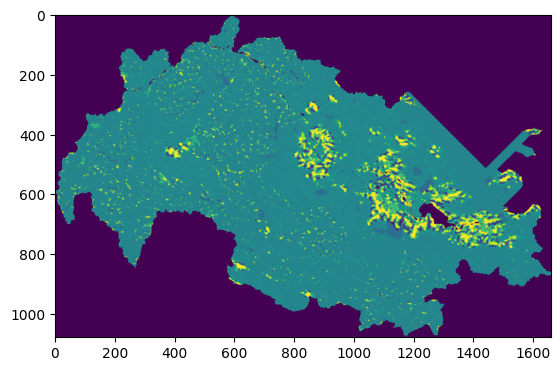

In [21]:
image_plot = rasterio.plot.show(data)